# 13 — Charts & map decorations

This notebook demos the remaining earthkit-plots primitives just added to Digital-Earth — all wired onto cleopatra/pyramids, all runnable offline on synthetic data:

- **Charts** (`digitalearth.charts`): `line`, `bar`, `histogram`.
- **Map decorations** (`Map`): `quiverkey`, `text` / `annotate` at lon/lat, `stock_img` backdrop.
- **Layout** (`digitalearth.scene`): `grid` multi-panel + `shared_colorbar`.

## Setup

Imports and a small synthetic field over Europe (EPSG:4326) plus a u/v wind pair.

In [1]:
%matplotlib inline
import numpy as np
from pyramids.dataset import Dataset
from digitalearth import charts
from digitalearth.scene import Map, grid, shared_colorbar

# A smooth synthetic field on a lon/lat grid covering Europe (-10..50 E, 30..70 N).
ny, nx = 80, 120
lon = np.linspace(-10, 50, nx)[None, :]
lat = np.linspace(70, 30, ny)[:, None]
field = (np.cos(np.deg2rad(lat)) * 20 + 10 * np.sin(np.deg2rad(lon * 3))).astype('float32')
GEO = (-10.0, 0.5, 0.0, 70.0, 0.0, -0.5)
FIELD = Dataset.create_from_array(arr=field, geo=GEO, epsg=4326)

# A coarse u/v wind pair on the same region for the quiver demo.
ny2, nx2 = 16, 24
la = np.linspace(70, 30, ny2)[:, None] * np.ones((1, nx2))
lo = np.linspace(-10, 50, nx2)[None, :] * np.ones((ny2, 1))
GEO2 = (-10.0, 2.5, 0.0, 70.0, 0.0, -2.5)
U = Dataset.create_from_array(arr=np.cos(np.deg2rad(la)).astype('float32'), geo=GEO2, epsg=4326)
V = Dataset.create_from_array(arr=(0.4 * np.sin(np.deg2rad(lo))).astype('float32'), geo=GEO2, epsg=4326)
print('field:', FIELD.rows, 'x', FIELD.columns)

2026-06-01 21:19:23 | INFO | pyramids.base.config | Logging is configured.


field: 80 x 120


## 1. Line chart — `charts.line`

An x–y line/marker plot. A 2-D `y` draws one line per column (e.g. ensemble members).

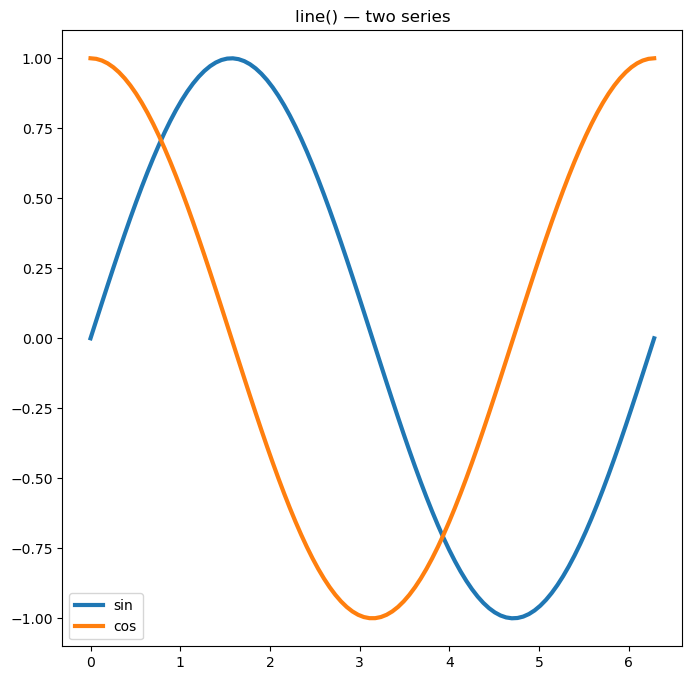

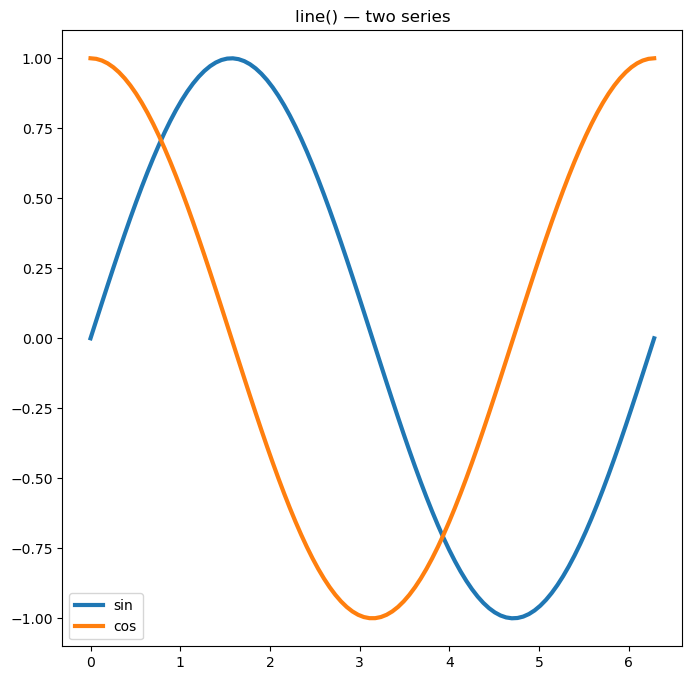

In [2]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.column_stack([np.sin(x), np.cos(x)])
ax = charts.line(x, y, label=['sin', 'cos'])
ax.legend(); ax.set_title('line() — two series')
ax.figure

## 2. Bar chart — `charts.bar`

A single-series bar chart (e.g. monthly totals).

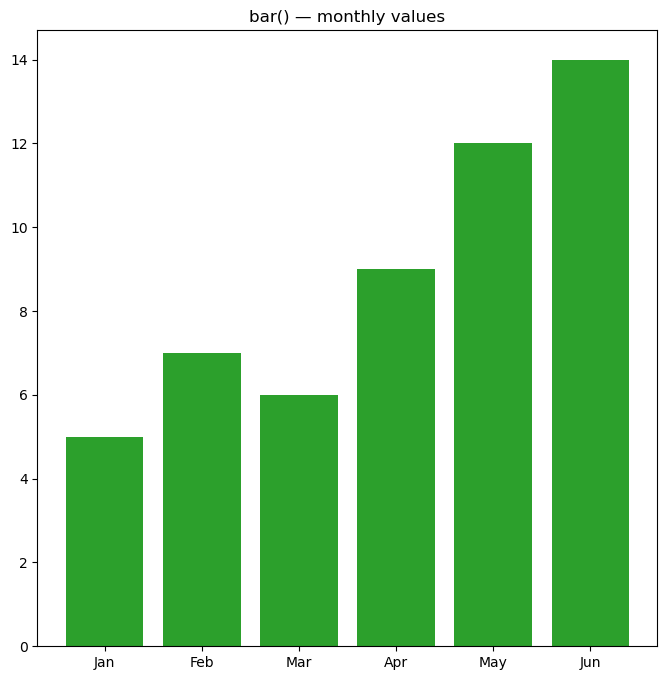

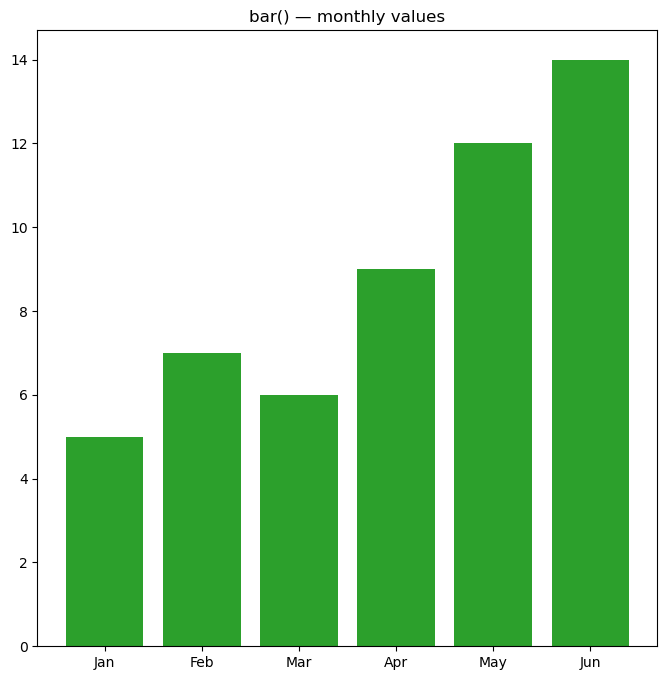

In [3]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
ax = charts.bar(range(len(months)), [5, 7, 6, 9, 12, 14], color='C2')
ax.set_xticks(range(len(months))); ax.set_xticklabels(months)
ax.set_title('bar() — monthly values')
ax.figure

## 3. Histogram — `charts.histogram`

Histogram of a raster's values. A pyramids `Dataset` is read over its first band with nodata dropped.

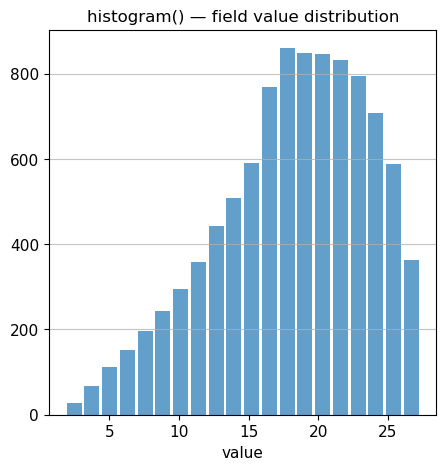

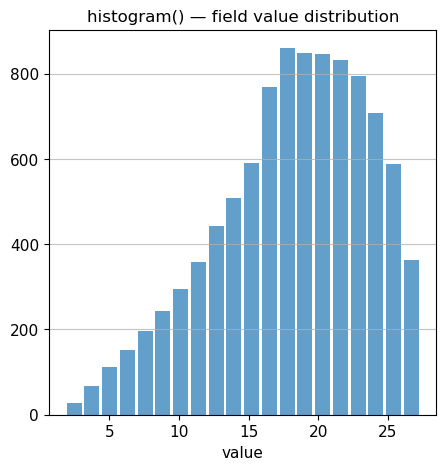

In [4]:
fig, ax, hist = charts.histogram(FIELD, bins=20, color=['#1f77b4'])
ax.set_title('histogram() — field value distribution'); ax.set_xlabel('value')
fig

## 4. Vector field + reference arrow — `Map.quiver` / `Map.quiverkey`

`quiverkey` draws the labelled reference arrow for the most recent `quiver` layer so the field is scaleable.

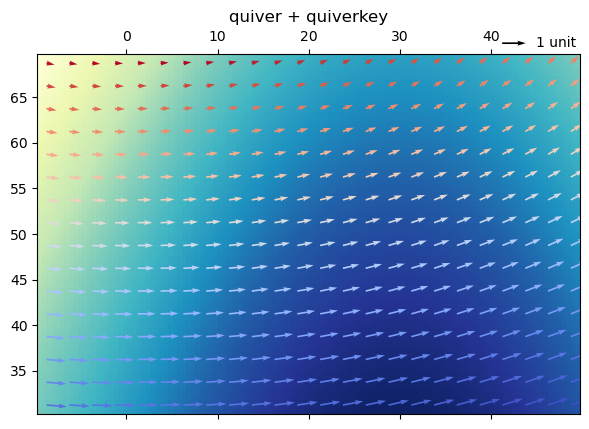

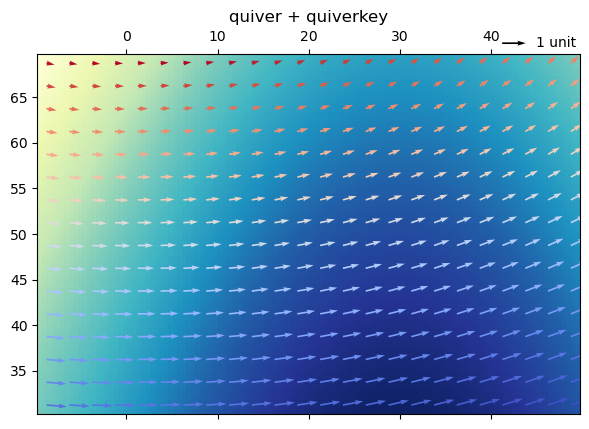

In [5]:
m = Map(crs=4326, figsize=(7, 5))
m.imshow(FIELD, cmap='YlGnBu')
m.quiver(U, V)
m.quiverkey(1.0, '1 unit', x=0.9, y=1.03)
m.set_title('quiver + quiverkey')
m.fig

## 5. Labels at lon/lat — `Map.text` / `Map.annotate`

`text`/`annotate` place labels at geographic points: the lon/lat is reprojected to the display CRS, so they land in the right place (and a far-side point on a globe is skipped).

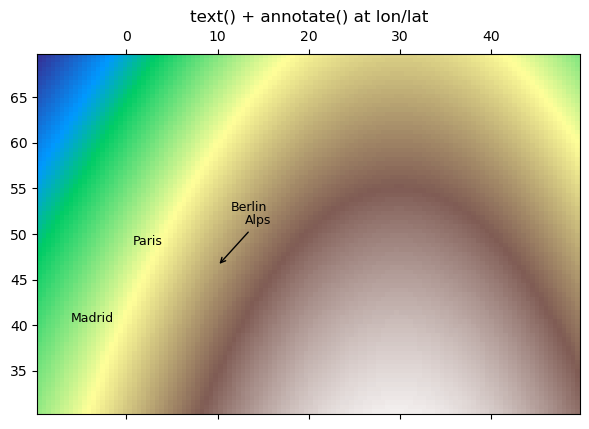

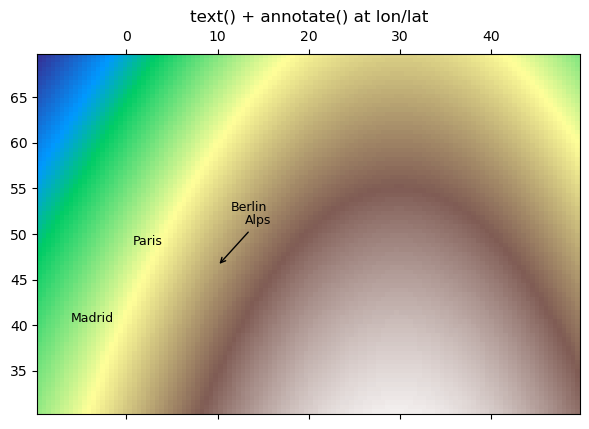

In [6]:
m = Map(crs=4326, figsize=(7, 5))
m.imshow(FIELD, cmap='terrain')
for name, lon_, lat_ in [('Paris', 2.35, 48.85), ('Berlin', 13.4, 52.5), ('Madrid', -3.7, 40.4)]:
    m.text(lon_, lat_, name, ha='center', fontsize=9, color='black')
m.annotate(10.0, 46.5, 'Alps', xytext=(20, 30), textcoords='offset points',
           arrowprops={'arrowstyle': '->'}, fontsize=9)
m.set_title('text() + annotate() at lon/lat')
m.fig

## 6. Background raster — `Map.stock_img`

`stock_img(dataset)` draws a backdrop raster **beneath** the data (low z-order, view preserved). Here the overlaid field has a nodata hole, so the grey backdrop shows through it.

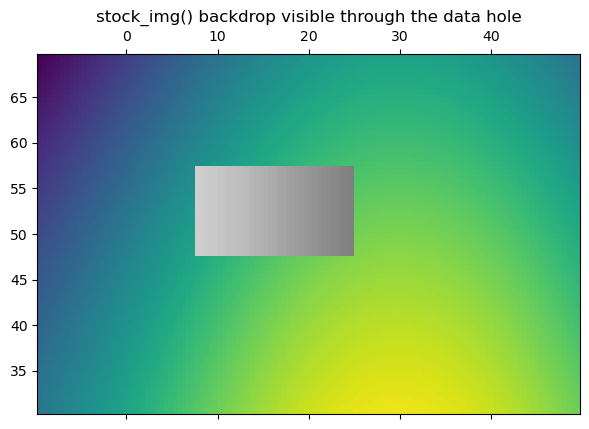

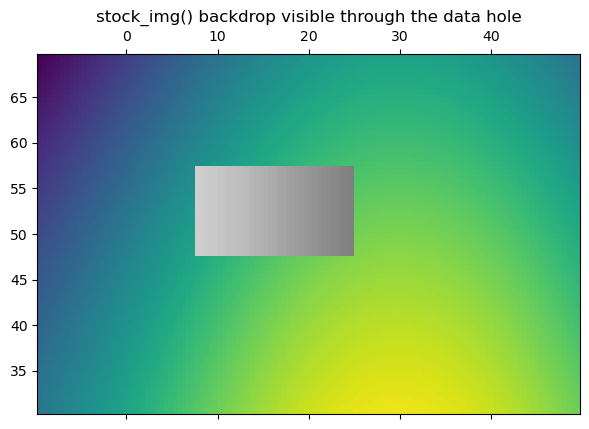

In [7]:
holed = field.copy()
holed[25:45, 35:70] = -9999.0          # carve a nodata rectangle
HOLED = Dataset.create_from_array(arr=holed, geo=GEO, epsg=4326)   # nodata defaults to -9999
backdrop = Dataset.create_from_array(arr=(np.zeros_like(field) + np.linspace(0, 30, nx)).astype('float32'),
                                     geo=GEO, epsg=4326)
m = Map(crs=4326, figsize=(7, 5))
m.stock_img(backdrop, cmap='Greys')    # backdrop, drawn beneath everything
m.imshow(HOLED, cmap='viridis')        # data with a hole -> backdrop shows through
m.set_title('stock_img() backdrop visible through the data hole')
m.fig

## 7. Multi-panel layout — `grid` + `shared_colorbar`

`grid(nrows, ncols)` returns one figure and a `Map` per cell; `shared_colorbar` adds a single colorbar spanning the panels.

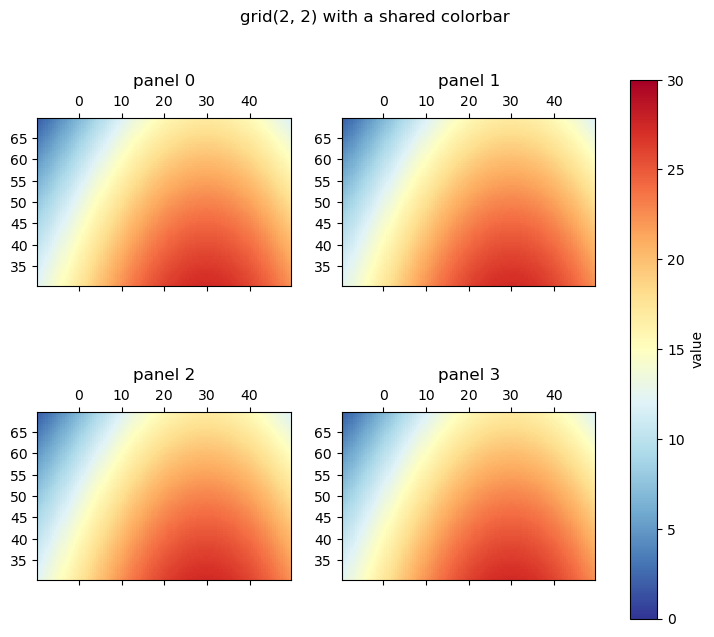

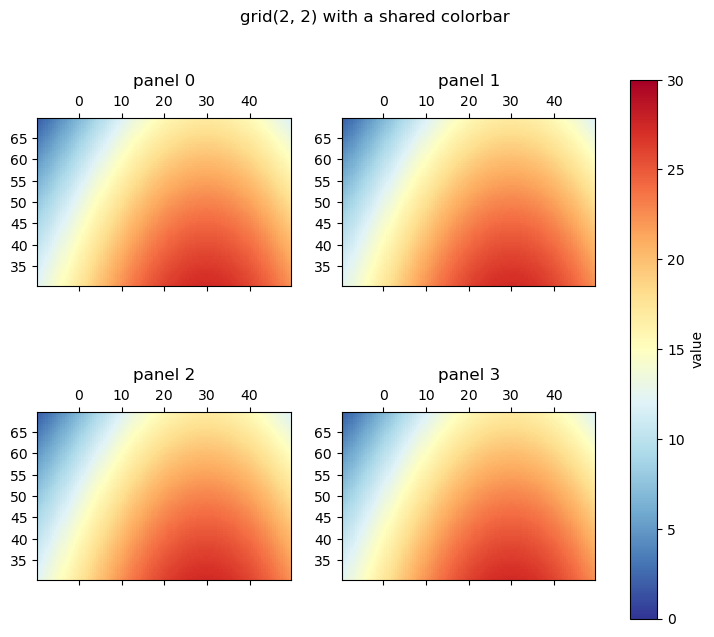

In [8]:
fig, maps = grid(2, 2, crs=4326, figsize=(9, 7))
im = None
for k, m in enumerate(maps):
    im = m.imshow(FIELD, cmap='RdYlBu_r', vmin=0, vmax=30)
    m.set_title(f'panel {k}')
shared_colorbar(fig, im, maps, label='value')
fig.suptitle('grid(2, 2) with a shared colorbar')
fig